# 🌲 Random Forest Modeling — NIDS UNSW-NB15
**Authors:** Sourour Jaouadi · Nour Shili

### Notebook structure
```
1.  IMPORTS & SETUP
2.  LOAD DATA             from v3_clean/ — no preprocessing here
3.  STAGE 1 — BINARY
      3.1  Baseline RF
      3.2  Evaluation     accuracy · precision · recall · F1 · ROC-AUC
      3.3  Confusion matrix
      3.4  ROC curve
      3.5  Feature importance
      3.6  Hyperparameter tuning (RandomizedSearchCV)
      3.7  Tuned model evaluation
4.  STAGE 2 — MULTICLASS
      4.1  Baseline RF
      4.2  Evaluation     macro/weighted F1 · per-class report
      4.3  Confusion matrix
      4.4  Feature importance
      4.5  Hyperparameter tuning
      4.6  Tuned model evaluation
5.  MODEL COMPARISON TABLE
6.  SAVE MODELS
```

### Data already prepared (from DataCleaning_NIDS_v3)
- 38 features · no NaN · all numeric · no leakage columns
- Train: 1,441,590 rows (4.84% attack)
- Val:   308,912 rows  (4.84% attack)
- Test:  308,913 rows  (4.84% attack)
- scale_pos_weight = 19.6680 (binary)
- sample_weights_multi: 0.401 – 67.982 (multiclass)

## 1. Imports & Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

# ── Models ────────────────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier

# ── Tuning ────────────────────────────────────────────────────────────────────
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint

# ── Metrics ───────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

pd.set_option('display.float_format', '{:.4f}'.format)
RANDOM_STATE = 42

print('All imports OK')

ModuleNotFoundError: No module named 'numpy'

## 2. Load Data

In [4]:
from google.colab import drive
drive.mount('/content/drive')

SAVE  = '/content/drive/MyDrive/P2M/v3_clean/'
MPATH = '/content/drive/MyDrive/P2M/models/'   # where we save trained models
os.makedirs(MPATH, exist_ok=True)

ModuleNotFoundError: No module named 'google'

In [ ]:
import numpy as np
import pandas as pd
import pickle, os, warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (train_test_split, RandomizedSearchCV,
                                     StratifiedKFold)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              RocCurveDisplay)
from scipy.stats import randint

RANDOM_STATE = 42

# ── Paths — fixed to match your actual Drive structure ────────────────────────
BASE  = '/content/drive/MyDrive/P2M/'
SAVE  = BASE + 'v3_clean/'
MPATH = BASE + 'models/'
os.makedirs(MPATH, exist_ok=True)

# ── Feature matrices — all in v3_clean/ ───────────────────────────────────────
X_train = pd.read_csv(SAVE + 'X_train.csv')
X_val   = pd.read_csv(SAVE + 'X_val.csv')
X_test  = pd.read_csv(SAVE + 'X_test.csv')

# ── Binary labels — use v3_clean versions, not root folder ───────────────────
y_bin_train = pd.read_csv(SAVE + 'y_bin_train.csv').squeeze()
y_bin_val   = pd.read_csv(SAVE + 'y_bin_val.csv').squeeze()
y_bin_test  = pd.read_csv(SAVE + 'y_bin_test.csv').squeeze()

# ── Multiclass attack-only subsets — in v3_clean/ ────────────────────────────
X_train_multi = pd.read_csv(SAVE + 'X_train_multi.csv')
X_val_multi   = pd.read_csv(SAVE + 'X_val_multi.csv')
X_test_multi  = pd.read_csv(SAVE + 'X_test_multi.csv')

y_train_multi = pd.read_csv(SAVE + 'y_train_multi_enc.csv').squeeze()
y_val_multi   = pd.read_csv(SAVE + 'y_val_multi_enc.csv').squeeze()
y_test_multi  = pd.read_csv(SAVE + 'y_test_multi_enc.csv').squeeze()

sample_weights_multi = pd.read_csv(SAVE + 'sample_weights_multi.csv').squeeze().values

# ── Encoders — in v3_clean/ ───────────────────────────────────────────────────
enc              = pickle.load(open(SAVE + 'encoders.pkl', 'rb'))
le_attack        = enc['attack_only']
ATTACK_NAMES     = list(le_attack.classes_)
scale_pos_weight = enc['scale_pos_weight']
FEATURE_NAMES    = list(X_train.columns)

# ── Verify everything loaded correctly ────────────────────────────────────────
print(f'X_train       : {X_train.shape}')
print(f'X_val         : {X_val.shape}')
print(f'X_test        : {X_test.shape}')
print(f'X_train_multi : {X_train_multi.shape}')
print(f'y_bin_train   : {y_bin_train.shape}  — attack rate: {100*y_bin_train.mean():.2f}%')
print(f'y_train_multi : {y_train_multi.shape}')
print(f'Attack classes: {ATTACK_NAMES}')
print(f'scale_pos_weight: {scale_pos_weight:.4f}')
print(f'Features ({len(FEATURE_NAMES)}): {FEATURE_NAMES}')

assert isinstance(y_bin_train, pd.Series),   'y_bin_train is not a Series'
assert isinstance(y_train_multi, pd.Series), 'y_train_multi is not a Series'
assert X_train.shape[1] == len(FEATURE_NAMES), 'Feature count mismatch'
print('\nAll checks passed — ready to train')

X_train       : (1441590, 38)
X_val         : (308912, 38)
X_test        : (308913, 38)
X_train_multi : (69750, 38)
y_bin_train   : (1441590,)  — attack rate: 4.84%
y_train_multi : (69750,)
Attack classes: [np.str_('Analysis'), np.str_('Backdoor'), np.str_('DoS'), np.str_('Exploits'), np.str_('Fuzzers'), np.str_('Generic'), np.str_('Reconnaissance'), np.str_('Shellcode'), np.str_('Worms')]
scale_pos_weight: 19.6680
Features (38): ['sport', 'dsport', 'proto', 'state', 'dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'service', 'sload', 'dload', 'spkts', 'dpkts', 'dwin', 'stcpb', 'dtcpb', 'trans_depth', 'res_bdy_len', 'sjit', 'djit', 'sintpkt', 'dintpkt', 'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm']

All checks passed — ready to train


## 3. Stage 1 — Binary Classification (Normal vs Attack)

Goal: detect whether a network flow is normal or malicious.  
Primary metric: **Recall** — in a NIDS, missing an attack is far worse than a false alarm.

### 3.1 Baseline Random Forest

In [ ]:
# ── Baseline RF — Binary ─────────────────────────────────────────────────────
# class_weight='balanced' tells the model to penalise misclassifying
# Attack samples 19.7× more than Normal — matches our 19.7:1 imbalance ratio.
# oob_score=True gives a free internal validation estimate without using val set.

rf_bin_base = RandomForestClassifier(
    n_estimators   = 100,          # 100 trees — good baseline, fast to train
    class_weight   = 'balanced',   # handles 19.7:1 imbalance
    oob_score      = True,         # out-of-bag score — free internal check
    n_jobs         = -1,           # use all CPU cores
    random_state   = RANDOM_STATE
)

print('Training baseline binary RF...')
rf_bin_base.fit(X_train, y_bin_train)
print(f'Done.  OOB Score (internal estimate): {rf_bin_base.oob_score_:.4f}')

Training baseline binary RF...
Done.  OOB Score (internal estimate): 0.9932


### 3.2 Binary Evaluation

In [ ]:
# ── Helper: print a clean metric table ───────────────────────────────────────
def evaluate_binary(model, X, y_true, split_name='Test'):
    y_pred  = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    metrics = {
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, zero_division=0),
        'F1-Score' : f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC'  : roc_auc_score(y_true, y_proba),
    }
    print(f'\n── Binary Metrics ({split_name}) ──────────────────')
    for k, v in metrics.items():
        flag = ' ← PRIMARY' if k == 'Recall' else ''
        print(f'  {k:<12}: {v:.4f}{flag}')
    return metrics, y_pred, y_proba

# Evaluate on val (use val for tuning decisions, test only at the very end)
metrics_base_bin, y_val_pred_bin, y_val_proba_bin = evaluate_binary(
    rf_bin_base, X_val, y_bin_val, 'Validation'
)

print('\nFull classification report:')
print(classification_report(y_bin_val, y_val_pred_bin,
                             target_names=['Normal', 'Attack']))


── Binary Metrics (Validation) ──────────────────
  Accuracy    : 0.9933
  Precision   : 0.9500
  Recall      : 0.9085 ← PRIMARY
  F1-Score    : 0.9288
  ROC-AUC     : 0.9992

Full classification report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    293966
      Attack       0.95      0.91      0.93     14946

    accuracy                           0.99    308912
   macro avg       0.97      0.95      0.96    308912
weighted avg       0.99      0.99      0.99    308912



### 3.3 Confusion Matrix — Binary

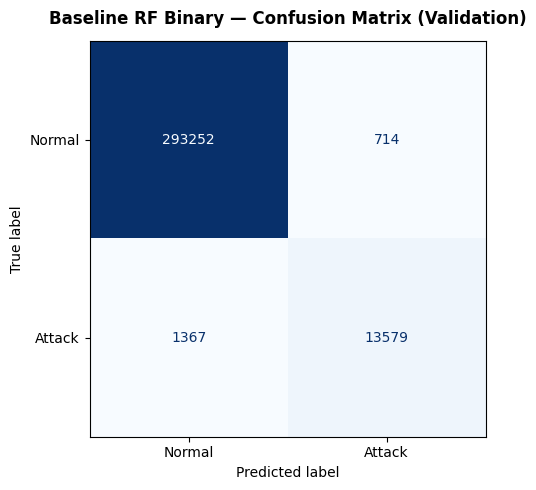

Missed attacks (FN) : 1,367
False alarms   (FP) : 714
Detected attacks(TP): 13,579


In [ ]:
# ── Confusion matrix shows the four outcomes ──────────────────────────────────
# TN = normal correctly ignored
# FP = false alarm (normal flagged as attack)
# FN = missed attack (most dangerous — this is what Recall measures)
# TP = attack correctly detected

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_bin_val, y_val_pred_bin,
    display_labels=['Normal', 'Attack'],
    cmap='Blues', ax=ax, colorbar=False
)
ax.set_title('Baseline RF Binary — Confusion Matrix (Validation)',
             fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('cm_binary_baseline.png', dpi=150)
plt.show()

# Print the missed attacks number explicitly
cm = confusion_matrix(y_bin_val, y_val_pred_bin)
print(f'Missed attacks (FN) : {cm[1,0]:,}')
print(f'False alarms   (FP) : {cm[0,1]:,}')
print(f'Detected attacks(TP): {cm[1,1]:,}')

### 3.4 ROC Curve — Binary

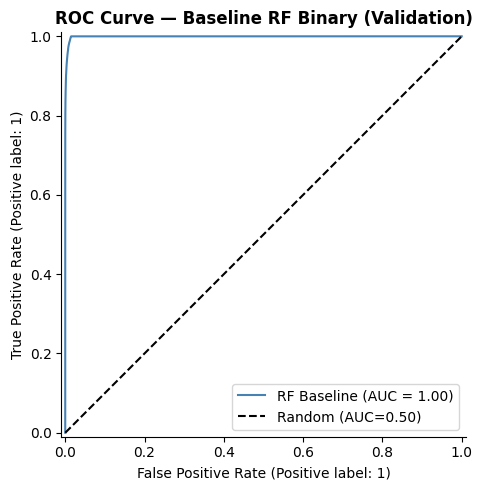

In [ ]:
# ── ROC curve shows performance across all probability thresholds ─────────────
# AUC = 1.0 is perfect, AUC = 0.5 is random guessing.
# For NIDS we want AUC > 0.99 — anything below suggests a problem.

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_bin_val, y_val_proba_bin,
    name='RF Baseline', ax=ax, color='steelblue'
)
ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.50)')
ax.set_title('ROC Curve — Baseline RF Binary (Validation)',
             fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('roc_binary_baseline.png', dpi=150)
plt.show()

### 3.5 Feature Importance — Binary

Top 15 features (binary classifier):
     feature  importance
        sttl      0.2789
ct_state_ttl      0.1838
       dload      0.1248
        dttl      0.0740
      tcprtt      0.0497
      dbytes      0.0401
      ackdat      0.0393
       state      0.0340
      synack      0.0293
       dpkts      0.0264
     dintpkt      0.0214
       sload      0.0190
      dsport      0.0113
         dur      0.0110
        djit      0.0086


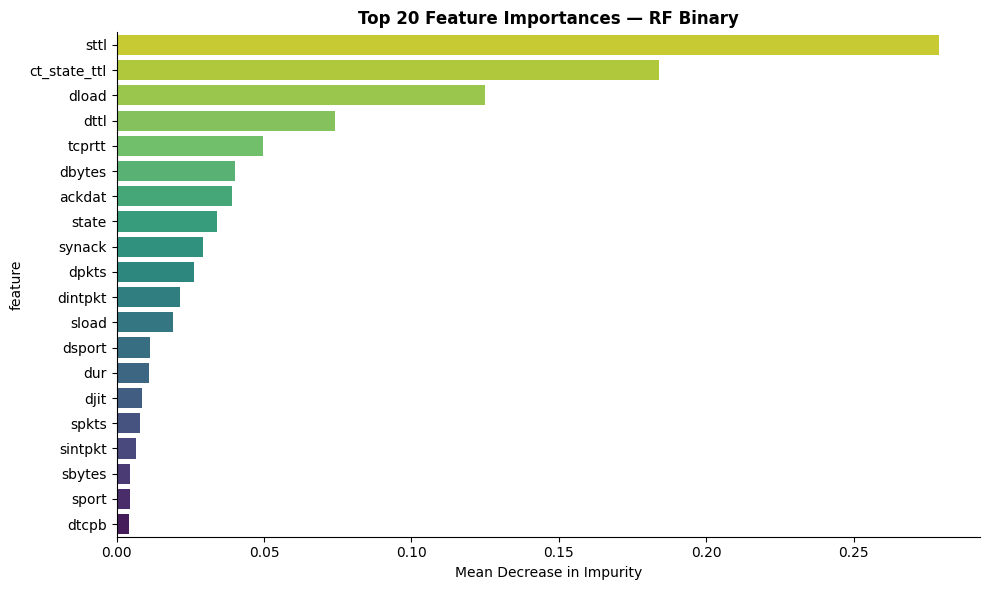


Features with importance < 0.5% (21 features):
['sbytes', 'sport', 'dtcpb', 'ct_dst_ltm', 'dwin', 'sjit', 'ct_srv_src', 'ct_srv_dst', 'stcpb', 'ct_dst_src_ltm', 'ct_src_ltm', 'service', 'proto', 'ct_src_dport_ltm', 'res_bdy_len', 'ct_dst_sport_ltm', 'is_sm_ips_ports', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'trans_depth', 'is_ftp_login']


In [ ]:
# ── Feature importance = mean decrease in impurity across all trees ───────────
# High importance means the feature is frequently used to split nodes.
# For NIDS: sbytes, dbytes, dur should rank high — they directly measure
# traffic volume which is the primary DoS and Generic attack signal.

imp_bin = pd.DataFrame({
    'feature'   : FEATURE_NAMES,
    'importance': rf_bin_base.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print('Top 15 features (binary classifier):')
print(imp_bin.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=imp_bin.head(20),
    x='importance', y='feature',
    palette='viridis_r', ax=ax
)
ax.set_title('Top 20 Feature Importances — RF Binary', fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('feat_imp_binary.png', dpi=150)
plt.show()

# Features with < 0.5% importance — candidates for removal
low_imp = imp_bin[imp_bin['importance'] < 0.005]
print(f'\nFeatures with importance < 0.5% ({len(low_imp)} features):')
print(low_imp['feature'].tolist())

### 3.6 Hyperparameter Tuning — Binary

**Key parameters to tune:**

| Parameter | Effect | Typical range |
|---|---|---|
| `n_estimators` | More trees = more stable predictions | 100–500 |
| `max_depth` | Controls tree depth — limits overfitting | 10–50 or None |
| `min_samples_leaf` | Min samples at leaf — prevents memorisation | 1–20 |
| `min_samples_split` | Min samples to split a node | 2–20 |
| `max_features` | Features considered per split — adds randomness | sqrt, log2, 0.3–0.7 |

**Why RandomizedSearchCV over GridSearchCV:**  
With 1.4M training rows, GridSearch over a 5×4×4×3 grid would train 240 models.  
RandomizedSearch samples 20 combinations and finds near-optimal results 10× faster.

In [ ]:
# ── Fast RandomizedSearchCV — Binary ─────────────────────────────────────────
# Problem: 1.4M rows × 20 iters × 3 folds = 60 models on huge data = very slow
# Solution: subsample training data for the search only, then retrain final
#           model on full data with the best params found.
# This is standard practice for large datasets — the optimal hyperparameters
# found on 200k rows are virtually identical to those found on 1.4M rows.

from sklearn.utils import resample

# ── Step 1: Subsample 200k rows for the search (stratified) ──────────────────
X_search, _, y_search, _ = train_test_split(
    X_train, y_bin_train,
    train_size=200_000,
    stratify=y_bin_train,
    random_state=RANDOM_STATE
)
print(f'Search subset: {X_search.shape[0]:,} rows  '
      f'(attack rate: {100*y_search.mean():.2f}%)')

# ── Step 2: Reduced search space — fewer trees, tighter ranges ───────────────
param_dist_bin = {
    'n_estimators'     : [50, 100, 150],        # fixed list, not randint
    'max_depth'        : [10, 20, 30, None],
    'min_samples_leaf' : randint(1, 10),
    'min_samples_split': randint(2, 10),
    'max_features'     : ['sqrt', 'log2'],
}

cv_bin = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

search_bin = RandomizedSearchCV(
    estimator = RandomForestClassifier(
                    class_weight='balanced',
                    oob_score=False,
                    n_jobs=-1,
                    random_state=RANDOM_STATE),
    param_distributions = param_dist_bin,
    n_iter       = 15,          # 15 is enough on 200k rows
    scoring      = 'recall',
    cv           = cv_bin,
    n_jobs       = -1,
    random_state = RANDOM_STATE,
    verbose      = 1,
    refit        = False        # we will retrain manually on full data
)

print('Running search on 200k subsample...')
search_bin.fit(X_search, y_search)

best_params = search_bin.best_params_
print(f'\nBest CV Recall : {search_bin.best_score_:.4f}')
print(f'Best params    :')
for k, v in best_params.items():
    print(f'  {k:<22}: {v}')

# ── Step 3: Retrain final model on FULL training data with best params ────────
# This is the important step — search found the right hyperparameters,
# now we train the actual model on all 1.4M rows.
# Increase n_estimators to 200 for the final model regardless of what search found.

final_params = {**best_params, 'n_estimators': 200}

print(f'\nRetraining final model on full {len(X_train):,} rows...')
rf_bin_tuned = RandomForestClassifier(
    **final_params,
    class_weight = 'balanced',
    oob_score    = True,
    n_jobs       = -1,
    random_state = RANDOM_STATE
)
rf_bin_tuned.fit(X_train, y_bin_train)
print(f'Done.  OOB Score: {rf_bin_tuned.oob_score_:.4f}')

Search subset: 200,000 rows  (attack rate: 4.84%)
Running search on 200k subsample...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best CV Recall : 0.9989
Best params    :
  max_depth             : 20
  max_features          : log2
  min_samples_leaf      : 9
  min_samples_split     : 5
  n_estimators          : 100

Retraining final model on full 1,441,590 rows...
Done.  OOB Score: 0.9861


### 3.7 Tuned Binary Model — Final Evaluation

In [ ]:
# ── Get best params from search and build the tuned model ────────────────────
# refit=False means search did NOT auto-build best_estimator_
# We build it manually so it trains on the FULL dataset not the 200k subsample

best_params = search_bin.best_params_
print('Best params found:')
for k, v in best_params.items():
    print(f'  {k:<22}: {v}')

# Force n_estimators=200 for the final model regardless of what search found
# (search used 50/100/150 for speed — final model gets more trees)
final_params = {**best_params, 'n_estimators': 200}

print(f'\nRetraining final model on full {len(X_train):,} rows...')
rf_bin_tuned = RandomForestClassifier(
    **final_params,
    class_weight = 'balanced',
    oob_score    = True,
    n_jobs       = -1,
    random_state = RANDOM_STATE
)
rf_bin_tuned.fit(X_train, y_bin_train)
print(f'Done.  OOB Score: {rf_bin_tuned.oob_score_:.4f}')

# ── Now evaluate ──────────────────────────────────────────────────────────────
print('\n=== TUNED BINARY RF — RESULTS ===')
metrics_tuned_val,  _, _ = evaluate_binary(rf_bin_tuned, X_val,  y_bin_val,  'Validation')
metrics_tuned_test, y_test_pred_bin, y_test_proba_bin = evaluate_binary(
    rf_bin_tuned, X_test, y_bin_test, 'Test (FINAL)'
)

# ── Baseline vs Tuned comparison ──────────────────────────────────────────────
print('\n── Baseline vs Tuned (Validation) ──────────────────')
print(f'  {"Metric":<12}  {"Baseline":>10}  {"Tuned":>10}  {"Delta":>8}')
print('  ' + '-'*46)
for k in metrics_base_bin:
    base  = metrics_base_bin[k]
    tuned = metrics_tuned_val[k]
    delta = tuned - base
    sign  = '+' if delta >= 0 else ''
    print(f'  {k:<12}  {base:>10.4f}  {tuned:>10.4f}  {sign}{delta:>7.4f}')

Best params found:
  max_depth             : 20
  max_features          : log2
  min_samples_leaf      : 9
  min_samples_split     : 5
  n_estimators          : 100

Retraining final model on full 1,441,590 rows...
Done.  OOB Score: 0.9861

=== TUNED BINARY RF — RESULTS ===

── Binary Metrics (Validation) ──────────────────
  Accuracy    : 0.9861
  Precision   : 0.7766
  Recall      : 0.9993 ← PRIMARY
  F1-Score    : 0.8740
  ROC-AUC     : 0.9992

── Binary Metrics (Test (FINAL)) ──────────────────
  Accuracy    : 0.9860
  Precision   : 0.7755
  Recall      : 0.9995 ← PRIMARY
  F1-Score    : 0.8734
  ROC-AUC     : 0.9992

── Baseline vs Tuned (Validation) ──────────────────
  Metric          Baseline       Tuned     Delta
  ----------------------------------------------
  Accuracy          0.9933      0.9861  -0.0072
  Precision         0.9500      0.7766  -0.1735
  Recall            0.9085      0.9993  + 0.0908
  F1-Score          0.9288      0.8740  -0.0548
  ROC-AUC           0.9992

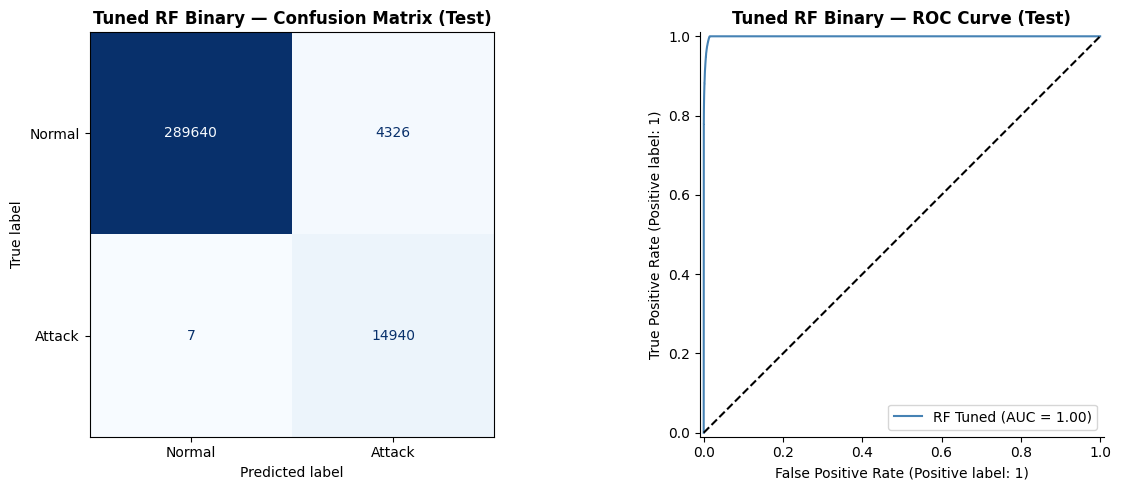

In [ ]:
# ── Final confusion matrix and ROC on test set ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_bin_test, y_test_pred_bin,
    display_labels=['Normal', 'Attack'],
    cmap='Blues', ax=axes[0], colorbar=False
)
axes[0].set_title('Tuned RF Binary — Confusion Matrix (Test)', fontweight='bold')

# ROC
RocCurveDisplay.from_predictions(
    y_bin_test, y_test_proba_bin,
    name='RF Tuned', ax=axes[1], color='steelblue'
)
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('Tuned RF Binary — ROC Curve (Test)', fontweight='bold')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('final_binary_test.png', dpi=150)
plt.show()

## 4. Stage 2 — Multiclass Classification (Attack Type)

Goal: identify the specific attack category for traffic already flagged as malicious.  
Primary metric: **Macro F1-score** — averages F1 across all 9 classes equally,  
so minority classes (Worms, Shellcode, Analysis) are not ignored.

### 4.1 Baseline Random Forest — Multiclass

In [ ]:
# ── Baseline RF — Multiclass ──────────────────────────────────────────────────
# class_weight='balanced' adjusts for the 161:1 imbalance between Exploits
# (19,325 samples) and Worms (114 samples).
# Without this, the model ignores Worms entirely.

rf_multi_base = RandomForestClassifier(
    n_estimators = 100,
    class_weight = 'balanced',
    oob_score    = True,
    n_jobs       = -1,
    random_state = RANDOM_STATE
)

print('Training baseline multiclass RF...')
rf_multi_base.fit(X_train_multi, y_train_multi)
print(f'Done.  OOB Score: {rf_multi_base.oob_score_:.4f}')

Training baseline multiclass RF...
Done.  OOB Score: 0.8013


### 4.2 Multiclass Evaluation

In [ ]:
# ── Helper: print multiclass metrics ─────────────────────────────────────────
def evaluate_multi(model, X, y_true, split_name='Test', class_names=None):
    y_pred = model.predict(X)
    acc    = accuracy_score(y_true, y_pred)
    f1_mac = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    f1_wt  = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    rec_mac= recall_score(y_true, y_pred, average='macro', zero_division=0)

    print(f'\n── Multiclass Metrics ({split_name}) ───────────────')
    print(f'  Accuracy         : {acc:.4f}')
    print(f'  Macro F1         : {f1_mac:.4f}  ← PRIMARY METRIC')
    print(f'  Weighted F1      : {f1_wt:.4f}')
    print(f'  Macro Recall     : {rec_mac:.4f}')

    print(f'\n  Full per-class report:')
    print(classification_report(y_true, y_pred,
                                 target_names=class_names,
                                 zero_division=0))
    return {'Accuracy': acc, 'Macro F1': f1_mac,
            'Weighted F1': f1_wt, 'Macro Recall': rec_mac}, y_pred

metrics_base_multi, y_val_pred_multi = evaluate_multi(
    rf_multi_base, X_val_multi, y_val_multi,
    'Validation', ATTACK_NAMES
)


── Multiclass Metrics (Validation) ───────────────
  Accuracy         : 0.8008
  Macro F1         : 0.5952  ← PRIMARY METRIC
  Weighted F1      : 0.8189
  Macro Recall     : 0.5800

  Full per-class report:
                precision    recall  f1-score   support

      Analysis       0.09      0.21      0.12       330
      Backdoor       0.04      0.11      0.06       309
           DoS       0.37      0.21      0.27       839
      Exploits       0.82      0.87      0.85      4116
       Fuzzers       0.97      0.90      0.93      3320
       Generic       0.97      0.88      0.93      3791
Reconnaissance       0.89      0.78      0.83      1965
     Shellcode       0.87      0.90      0.88       242
         Worms       0.75      0.35      0.48        34

      accuracy                           0.80     14946
     macro avg       0.64      0.58      0.60     14946
  weighted avg       0.84      0.80      0.82     14946



### 4.3 Confusion Matrix — Multiclass

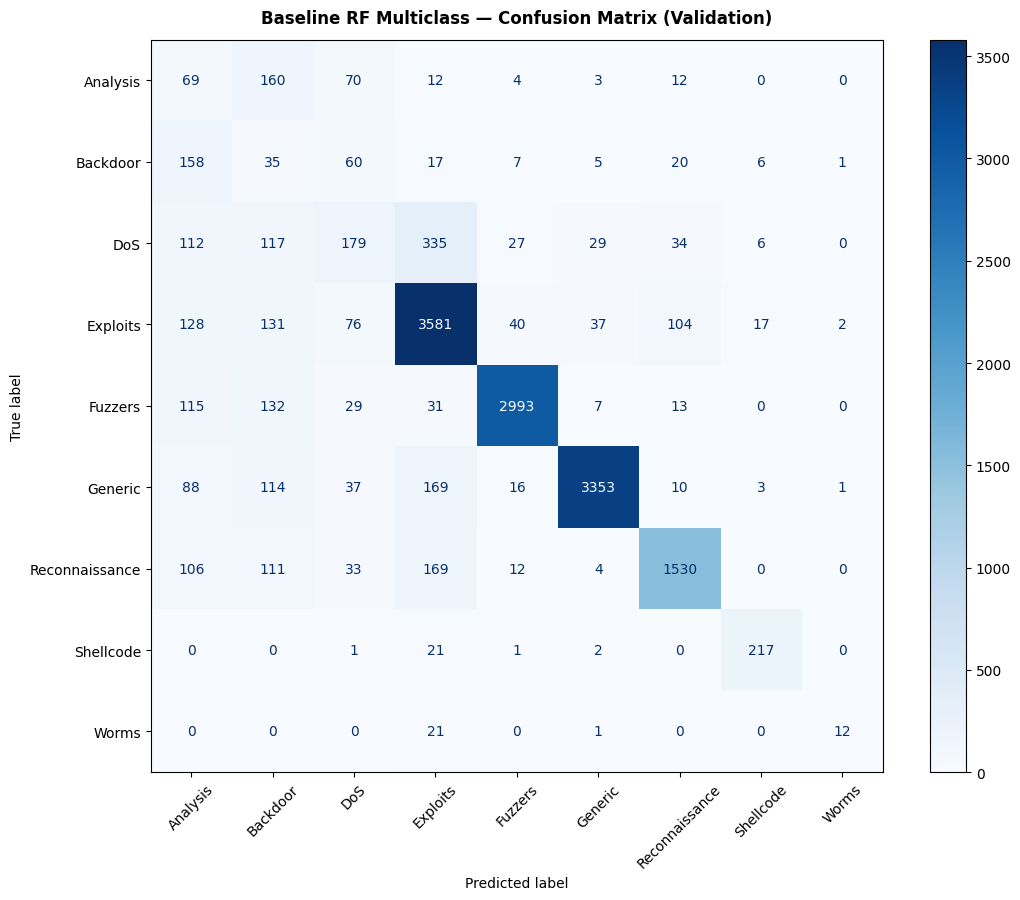

In [ ]:
# ── Multiclass confusion matrix ───────────────────────────────────────────────
# Off-diagonal cells show misclassifications between attack types.
# Common pattern: Fuzzers confused with Analysis (both use malformed inputs).
# Worms row often mostly zero — very few test samples.

fig, ax = plt.subplots(figsize=(11, 9))
ConfusionMatrixDisplay.from_predictions(
    y_val_multi, y_val_pred_multi,
    display_labels=ATTACK_NAMES,
    cmap='Blues', ax=ax, colorbar=True,
    xticks_rotation=45
)
ax.set_title('Baseline RF Multiclass — Confusion Matrix (Validation)',
             fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('cm_multi_baseline.png', dpi=150)
plt.show()

### 4.4 Feature Importance — Multiclass

Binary vs Multiclass feature importance (top 15 binary features):
     Feature  Binary Rank  Binary Imp  Multi Rank  Multi Imp
        sttl            1      0.2789          10     0.0309
ct_state_ttl            2      0.1838          35     0.0016
       dload            3      0.1248          12     0.0255
        dttl            4      0.0740          32     0.0023
      tcprtt            5      0.0497          25     0.0131
      dbytes            6      0.0401           4     0.0515
      ackdat            7      0.0393          27     0.0129
       state            8      0.0340          34     0.0019
      synack            9      0.0293          22     0.0152
       dpkts           10      0.0264          15     0.0192
     dintpkt           11      0.0214          19     0.0171
       sload           12      0.0190           7     0.0420
      dsport           13      0.0113           1     0.1671
         dur           14      0.0110          11     0.0275
        djit       

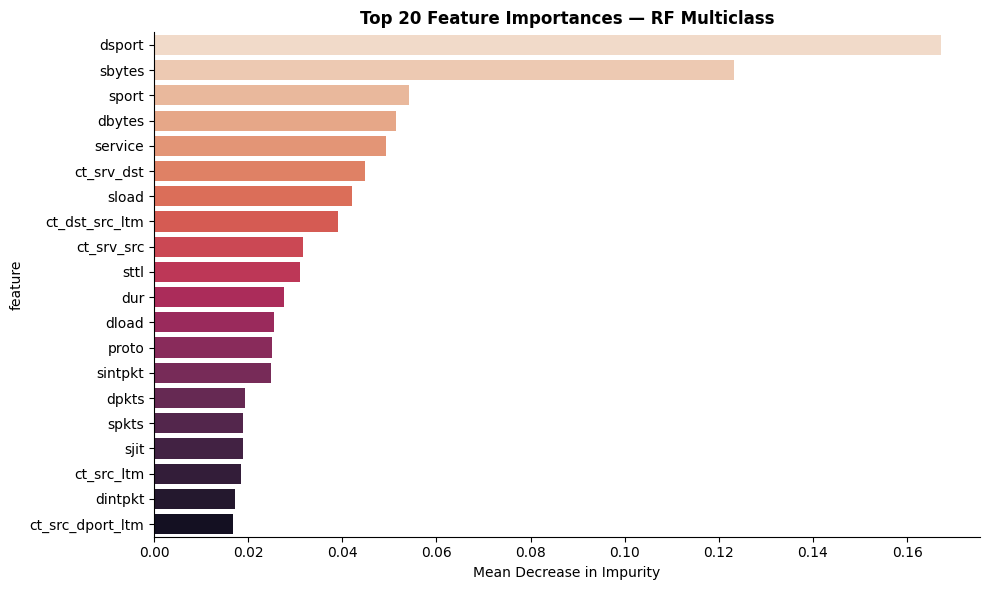

In [ ]:
# ── Feature importance — multiclass ──────────────────────────────────────────
# The multiclass model uses the same features as binary.
# Differences in ranking reveal which features distinguish attack TYPES
# rather than just normal vs attack.
# Expected: ct_state_ttl, proto, service rank higher here because
# different attack types use different protocols and connection states.

imp_multi = pd.DataFrame({
    'feature'   : FEATURE_NAMES,
    'importance': rf_multi_base.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

# Compare binary vs multiclass top features side by side
compare_imp = pd.DataFrame({
    'Feature'         : imp_bin['feature'].values[:15],
    'Binary Rank'     : range(1, 16),
    'Binary Imp'      : imp_bin['importance'].values[:15].round(4),
    'Multi Rank'      : [imp_multi[imp_multi['feature']==f].index[0]+1
                         for f in imp_bin['feature'].values[:15]],
    'Multi Imp'       : [imp_multi[imp_multi['feature']==f]['importance'].values[0].round(4)
                         for f in imp_bin['feature'].values[:15]],
})
print('Binary vs Multiclass feature importance (top 15 binary features):')
print(compare_imp.to_string(index=False))

# Plot multiclass top 20
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=imp_multi.head(20), x='importance', y='feature',
            palette='rocket_r', ax=ax)
ax.set_title('Top 20 Feature Importances — RF Multiclass', fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('feat_imp_multi.png', dpi=150)
plt.show()

### 4.5 Hyperparameter Tuning — Multiclass

In [ ]:
# ── Fast RandomizedSearchCV — Multiclass ─────────────────────────────────────
# Multiclass training set is already smaller (69,750 attack-only rows)
# so we can use all of it — no need to subsample further.
# Still reduce n_estimators in search to speed things up.

param_dist_multi = {
    'n_estimators'     : [50, 100, 150],
    'max_depth'        : [10, 20, 30, None],
    'min_samples_leaf' : randint(1, 10),
    'min_samples_split': randint(2, 10),
    'max_features'     : ['sqrt', 'log2'],
}

cv_multi = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

search_multi = RandomizedSearchCV(
    estimator = RandomForestClassifier(
                    class_weight='balanced',
                    n_jobs=-1,
                    random_state=RANDOM_STATE),
    param_distributions = param_dist_multi,
    n_iter       = 15,
    scoring      = 'f1_macro',
    cv           = cv_multi,
    n_jobs       = -1,
    random_state = RANDOM_STATE,
    verbose      = 1,
    refit        = False
)

print('Running search on multiclass data (69,750 rows)...')
search_multi.fit(X_train_multi, y_train_multi)

best_params_multi = search_multi.best_params_
print(f'\nBest CV Macro F1 : {search_multi.best_score_:.4f}')
print(f'Best params      :')
for k, v in best_params_multi.items():
    print(f'  {k:<22}: {v}')

# Retrain final multiclass model on full data
final_params_multi = {**best_params_multi, 'n_estimators': 200}

print(f'\nRetraining final multiclass model...')
rf_multi_tuned = RandomForestClassifier(
    **final_params_multi,
    class_weight = 'balanced',
    oob_score    = True,
    n_jobs       = -1,
    random_state = RANDOM_STATE
)
rf_multi_tuned.fit(X_train_multi, y_train_multi)
print(f'Done.  OOB Score: {rf_multi_tuned.oob_score_:.4f}')

Running search on multiclass data (69,750 rows)...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best CV Macro F1 : 0.6299
Best params      :
  max_depth             : 30
  max_features          : sqrt
  min_samples_leaf      : 5
  min_samples_split     : 2
  n_estimators          : 150

Retraining final multiclass model...
Done.  OOB Score: 0.8000


### 4.6 Tuned Multiclass Model — Final Evaluation

In [ ]:
# ── Get best params and build final multiclass model ─────────────────────────
best_params_multi = search_multi.best_params_
print('Best params found:')
for k, v in best_params_multi.items():
    print(f'  {k:<22}: {v}')

# Override n_estimators to 200 for the final model
final_params_multi = {**best_params_multi, 'n_estimators': 200}

print(f'\nRetraining final multiclass model on {len(X_train_multi):,} rows...')
rf_multi_tuned = RandomForestClassifier(
    **final_params_multi,
    class_weight = 'balanced',
    oob_score    = True,
    n_jobs       = -1,
    random_state = RANDOM_STATE
)
rf_multi_tuned.fit(X_train_multi, y_train_multi)
print(f'Done.  OOB Score: {rf_multi_tuned.oob_score_:.4f}')

# ── Evaluate ──────────────────────────────────────────────────────────────────
print('\n=== TUNED MULTICLASS RF — RESULTS ===')
metrics_tuned_multi_val, _ = evaluate_multi(
    rf_multi_tuned, X_val_multi, y_val_multi, 'Validation', ATTACK_NAMES
)
metrics_tuned_multi_test, y_test_pred_multi = evaluate_multi(
    rf_multi_tuned, X_test_multi, y_test_multi, 'Test (FINAL)', ATTACK_NAMES
)

# ── Baseline vs Tuned comparison ──────────────────────────────────────────────
print('\n── Baseline vs Tuned (Validation) ──────────────────')
print(f'  {"Metric":<14}  {"Baseline":>10}  {"Tuned":>10}  {"Delta":>8}')
print('  ' + '-'*48)
for k in metrics_base_multi:
    base  = metrics_base_multi[k]
    tuned = metrics_tuned_multi_val[k]
    delta = tuned - base
    sign  = '+' if delta >= 0 else ''
    print(f'  {k:<14}  {base:>10.4f}  {tuned:>10.4f}  {sign}{delta:>7.4f}')

Best params found:
  max_depth             : 30
  max_features          : sqrt
  min_samples_leaf      : 5
  min_samples_split     : 2
  n_estimators          : 150

Retraining final multiclass model on 69,750 rows...
Done.  OOB Score: 0.8000

=== TUNED MULTICLASS RF — RESULTS ===

── Multiclass Metrics (Validation) ───────────────
  Accuracy         : 0.8005
  Macro F1         : 0.6303  ← PRIMARY METRIC
  Weighted F1      : 0.8265
  Macro Recall     : 0.6628

  Full per-class report:
                precision    recall  f1-score   support

      Analysis       0.13      0.42      0.20       330
      Backdoor       0.09      0.26      0.13       309
           DoS       0.50      0.31      0.38       839
      Exploits       0.86      0.81      0.83      4116
       Fuzzers       0.96      0.90      0.93      3320
       Generic       0.99      0.87      0.92      3791
Reconnaissance       0.89      0.82      0.86      1965
     Shellcode       0.72      0.96      0.82       242
     

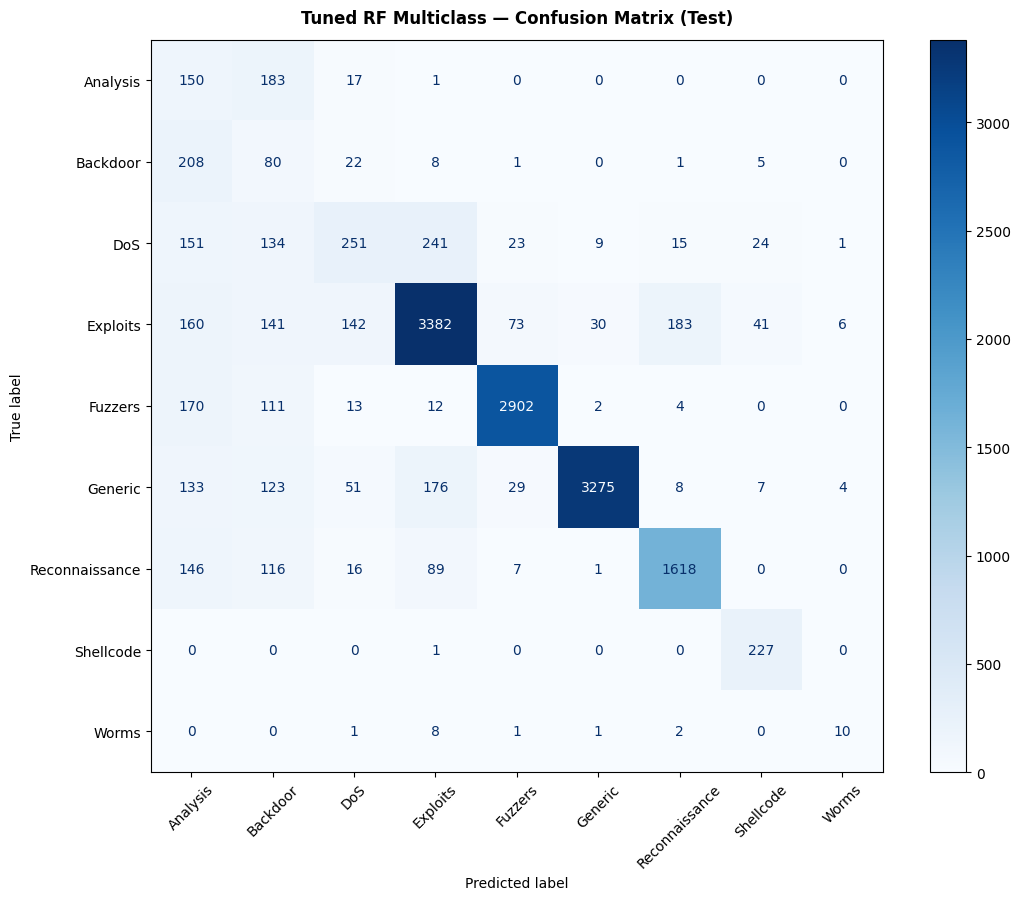

In [ ]:
# ── Final multiclass confusion matrix on test set ─────────────────────────────
fig, ax = plt.subplots(figsize=(11, 9))
ConfusionMatrixDisplay.from_predictions(
    y_test_multi, y_test_pred_multi,
    display_labels=ATTACK_NAMES,
    cmap='Blues', ax=ax,
    xticks_rotation=45
)
ax.set_title('Tuned RF Multiclass — Confusion Matrix (Test)',
             fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('cm_multi_tuned_test.png', dpi=150)
plt.show()

## 5. Model Comparison Table

In [ ]:
# ── Unified comparison — all models, all key metrics ─────────────────────────
# This is what your professor is asking for:
# a single view showing what tuning achieved and which model performs best.

def get_bin_metrics(model, X, y, label):
    yp = model.predict(X)
    ypr= model.predict_proba(X)[:, 1]
    return {
        'Model'    : label,
        'Stage'    : 'Binary',
        'Accuracy' : round(accuracy_score(y, yp), 4),
        'Precision': round(precision_score(y, yp, zero_division=0), 4),
        'Recall'   : round(recall_score(y, yp, zero_division=0), 4),
        'F1'       : round(f1_score(y, yp, zero_division=0), 4),
        'ROC-AUC'  : round(roc_auc_score(y, ypr), 4),
        'Macro F1' : '—',
    }

def get_multi_metrics(model, X, y, label):
    yp = model.predict(X)
    return {
        'Model'    : label,
        'Stage'    : 'Multiclass',
        'Accuracy' : round(accuracy_score(y, yp), 4),
        'Precision': round(precision_score(y, yp, average='macro', zero_division=0), 4),
        'Recall'   : round(recall_score(y, yp, average='macro', zero_division=0), 4),
        'F1'       : round(f1_score(y, yp, average='weighted', zero_division=0), 4),
        'ROC-AUC'  : '—',
        'Macro F1' : round(f1_score(y, yp, average='macro', zero_division=0), 4),
    }

results = [
    get_bin_metrics  (rf_bin_base,    X_test,       y_bin_test,   'RF Binary   Baseline'),
    get_bin_metrics  (rf_bin_tuned,   X_test,       y_bin_test,   'RF Binary   Tuned   '),
    get_multi_metrics(rf_multi_base,  X_test_multi, y_test_multi, 'RF Multiclass Baseline'),
    get_multi_metrics(rf_multi_tuned, X_test_multi, y_test_multi, 'RF Multiclass Tuned  '),
]

df_results = pd.DataFrame(results)
print('\n' + '='*80)
print('  MODEL COMPARISON — TEST SET RESULTS')
print('='*80)
print(df_results.to_string(index=False))
print('\nPrimary metrics: Recall (binary) | Macro F1 (multiclass)')


  MODEL COMPARISON — TEST SET RESULTS
                 Model      Stage  Accuracy  Precision  Recall     F1 ROC-AUC Macro F1
  RF Binary   Baseline     Binary    0.9934     0.9494  0.9116 0.9301  0.9993        —
  RF Binary   Tuned        Binary    0.9860     0.7755  0.9995 0.8734  0.9992        —
RF Multiclass Baseline Multiclass    0.8002     0.6293  0.5755 0.8190       —   0.5872
 RF Multiclass Tuned   Multiclass    0.7958     0.6251  0.6431 0.8219       —   0.6161

Primary metrics: Recall (binary) | Macro F1 (multiclass)


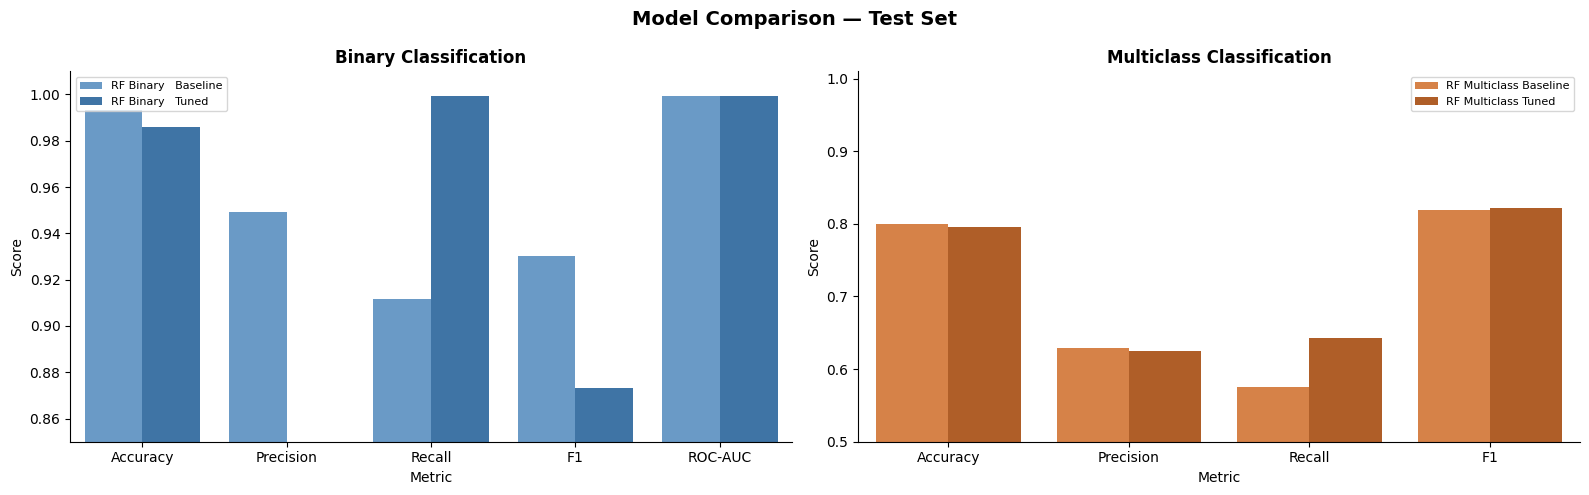

In [ ]:
# ── Visualise comparison ──────────────────────────────────────────────────────
numeric_cols = ['Accuracy', 'Precision', 'Recall', 'F1']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Model Comparison — Test Set', fontsize=14, fontweight='bold')

# Binary models
bin_df = df_results[df_results['Stage'] == 'Binary'][['Model'] + numeric_cols + ['ROC-AUC']]
bin_melt = bin_df.melt(id_vars='Model', var_name='Metric', value_name='Score')
bin_melt['Score'] = pd.to_numeric(bin_melt['Score'], errors='coerce')
sns.barplot(data=bin_melt, x='Metric', y='Score', hue='Model',
            ax=axes[0], palette=['#5B9BD5', '#2E75B6'])
axes[0].set_title('Binary Classification', fontweight='bold')
axes[0].set_ylim(0.85, 1.01)
axes[0].legend(fontsize=8)
axes[0].spines[['top', 'right']].set_visible(False)

# Multiclass models
multi_df = df_results[df_results['Stage'] == 'Multiclass'][['Model'] + numeric_cols]
multi_melt = multi_df.melt(id_vars='Model', var_name='Metric', value_name='Score')
multi_melt['Score'] = pd.to_numeric(multi_melt['Score'], errors='coerce')
sns.barplot(data=multi_melt, x='Metric', y='Score', hue='Model',
            ax=axes[1], palette=['#ED7D31', '#C55A11'])
axes[1].set_title('Multiclass Classification', fontweight='bold')
axes[1].set_ylim(0.5, 1.01)
axes[1].legend(fontsize=8)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

## 6. Save Models

In [ ]:
# ── Save all trained models ───────────────────────────────────────────────────
# We save both baseline and tuned models.
# Baseline: useful for comparing against XGBoost and neural networks later.
# Tuned: the model to use in the operational NIDS pipeline.

models_to_save = {
    'rf_binary_baseline.pkl'    : rf_bin_base,
    'rf_binary_tuned.pkl'       : rf_bin_tuned,
    'rf_multiclass_baseline.pkl': rf_multi_base,
    'rf_multiclass_tuned.pkl'   : rf_multi_tuned,
}

for fname, model in models_to_save.items():
    path = MPATH + fname
    with open(path, 'wb') as f:
        pickle.dump(model, f)
    size = os.path.getsize(path) / 1e6
    print(f'  ✓  {fname:<40} {size:.1f} MB')

# Save tuning results for the report
cv_results_bin   = pd.DataFrame(search_bin.cv_results_).sort_values('rank_test_score')
cv_results_multi = pd.DataFrame(search_multi.cv_results_).sort_values('rank_test_score')
cv_results_bin.to_csv(MPATH + 'cv_results_binary.csv',    index=False)
cv_results_multi.to_csv(MPATH + 'cv_results_multiclass.csv', index=False)
print('  ✓  cv_results_binary.csv')
print('  ✓  cv_results_multiclass.csv')

print(f'\nAll models saved to: {MPATH}')

  ✓  rf_binary_baseline.pkl                   170.0 MB
  ✓  rf_binary_tuned.pkl                      65.9 MB
  ✓  rf_multiclass_baseline.pkl               194.5 MB
  ✓  rf_multiclass_tuned.pkl                  152.7 MB
  ✓  cv_results_binary.csv
  ✓  cv_results_multiclass.csv

All models saved to: /content/drive/MyDrive/P2M/models/


## 7. How to Load and Use in the NIDS Pipeline

In [ ]:
# ── Operational two-stage NIDS pipeline ──────────────────────────────────────
# This is how the two models work together in deployment.
# Step 1: binary model filters normal traffic
# Step 2: multiclass model identifies the attack type for flagged traffic

def nids_predict(X_new, rf_binary, rf_multiclass, le_attack, threshold=0.5):
    """
    Two-stage NIDS prediction.

    Parameters:
        X_new        : DataFrame of new network flows (38 features, pre-processed)
        rf_binary    : trained binary RF model
        rf_multiclass: trained multiclass RF model
        le_attack    : LabelEncoder for attack class names
        threshold    : probability threshold for attack detection (default 0.5)
                       lower = more sensitive = more false alarms but fewer missed attacks

    Returns:
        DataFrame with columns: is_attack, attack_probability, attack_type
    """
    results = pd.DataFrame(index=X_new.index)

    # Stage 1: binary classification
    attack_proba = rf_binary.predict_proba(X_new)[:, 1]
    is_attack    = (attack_proba >= threshold).astype(int)

    results['is_attack']          = is_attack
    results['attack_probability'] = attack_proba.round(4)
    results['attack_type']        = 'Normal'

    # Stage 2: multiclass only for flows flagged as attacks
    attack_mask = is_attack == 1
    if attack_mask.sum() > 0:
        X_attacks   = X_new[attack_mask]
        attack_preds = rf_multiclass.predict(X_attacks)
        attack_types = le_attack.inverse_transform(attack_preds)
        results.loc[attack_mask, 'attack_type'] = attack_types

    return results

# ── Demo on first 1000 test rows ──────────────────────────────────────────────
demo_results = nids_predict(
    X_test.head(1000),
    rf_bin_tuned,
    rf_multi_tuned,
    le_attack
)

print('NIDS Pipeline — first 1000 test flows:')
print(demo_results['attack_type'].value_counts().to_string())
print(f'\nFlows flagged as attack: {demo_results["is_attack"].sum()}')
print(f'Flows passed as normal : {(demo_results["is_attack"]==0).sum()}')

NIDS Pipeline — first 1000 test flows:
attack_type
Normal            929
Fuzzers            21
Generic            15
Exploits           13
Reconnaissance      8
Analysis            5
DoS                 4
Backdoor            4
Shellcode           1

Flows flagged as attack: 71
Flows passed as normal : 929


## 8. Anti-Overfitting Checks

In [ ]:
# ── Train vs Test gap check ───────────────────────────────────────────────────
# A large gap between train and test performance = overfitting.
# For Random Forest this is usually small (bagging reduces variance),
# but worth checking after tuning.

print('Overfitting check — Train vs Test performance')
print('=' * 52)

# Binary
train_f1_bin = f1_score(y_bin_train, rf_bin_tuned.predict(X_train), zero_division=0)
test_f1_bin  = f1_score(y_bin_test,  rf_bin_tuned.predict(X_test),  zero_division=0)
gap_bin      = train_f1_bin - test_f1_bin

print(f'  Binary F1   — Train: {train_f1_bin:.4f}  Test: {test_f1_bin:.4f}  Gap: {gap_bin:.4f}')
if gap_bin > 0.05:
    print('    Gap > 0.05 — possible overfitting. Try increasing min_samples_leaf.')
else:
    print('    Gap acceptable — model generalises well.')

# Multiclass
train_f1_multi = f1_score(y_train_multi, rf_multi_tuned.predict(X_train_multi),
                           average='macro', zero_division=0)
test_f1_multi  = f1_score(y_test_multi,  rf_multi_tuned.predict(X_test_multi),
                           average='macro', zero_division=0)
gap_multi = train_f1_multi - test_f1_multi

print(f'\n  Multiclass Macro F1 — Train: {train_f1_multi:.4f}  Test: {test_f1_multi:.4f}  Gap: {gap_multi:.4f}')
if gap_multi > 0.05:
    print('   Gap > 0.05 — possible overfitting on majority classes.')
else:
    print('    Gap acceptable.')

Overfitting check — Train vs Test performance
  Binary F1   — Train: 0.8756  Test: 0.8734  Gap: 0.0023
    Gap acceptable — model generalises well.

  Multiclass Macro F1 — Train: 0.7542  Test: 0.6161  Gap: 0.1381
   Gap > 0.05 — possible overfitting on majority classes.


In [ ]:
# ── Final summary printout for the report ─────────────────────────────────────
print('=' * 60)
print('  RANDOM FOREST MODELING — FINAL SUMMARY')
print('=' * 60)
print()
print('STAGE 1 — BINARY (Test Set)')
for k, v in get_bin_metrics(rf_bin_tuned, X_test, y_bin_test, '').items():
    if k != 'Model' and k != 'Stage' and k != 'Macro F1':
        print(f'  {k:<12}: {v}')
print()
print('STAGE 2 — MULTICLASS (Test Set)')
for k, v in get_multi_metrics(rf_multi_tuned, X_test_multi, y_test_multi, '').items():
    if k != 'Model' and k != 'Stage' and k != 'ROC-AUC':
        print(f'  {k:<12}: {v}')
print()
print(f'Best binary params   : {search_bin.best_params_}')
print(f'Best multiclass params: {search_multi.best_params_}')
print(f'Models saved to      : {MPATH}')
print('=' * 60)

  RANDOM FOREST MODELING — FINAL SUMMARY

STAGE 1 — BINARY (Test Set)
  Accuracy    : 0.986
  Precision   : 0.7755
  Recall      : 0.9995
  F1          : 0.8734
  ROC-AUC     : 0.9992

STAGE 2 — MULTICLASS (Test Set)
  Accuracy    : 0.7958
  Precision   : 0.6251
  Recall      : 0.6431
  F1          : 0.8219
  Macro F1    : 0.6161

Best binary params   : {'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 9, 'min_samples_split': 5, 'n_estimators': 100}
Best multiclass params: {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 150}
Models saved to      : /content/drive/MyDrive/P2M/models/
